<a href="https://colab.research.google.com/github/krishnakanthkona-3110/Interview_Prep/blob/main/Interview_Notes_Nueral_Networks_Deep_Understanding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

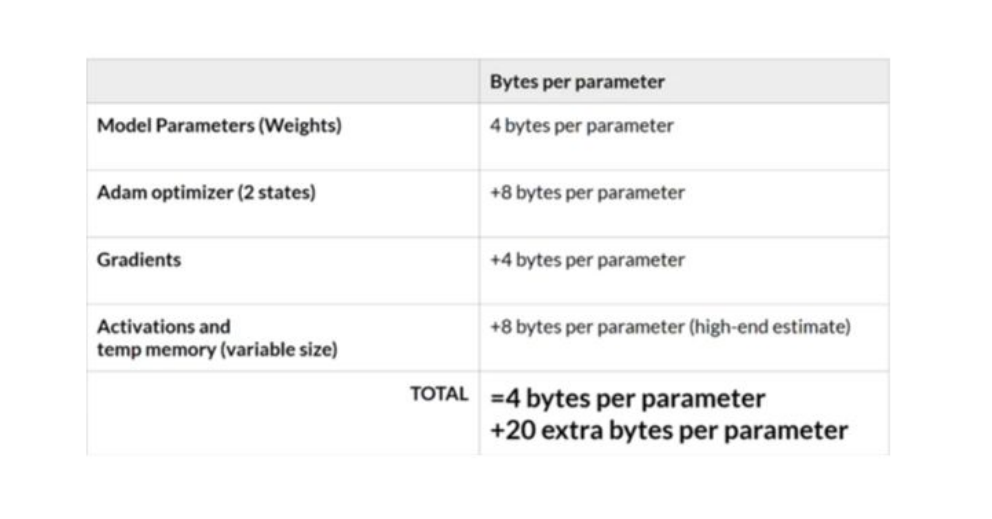

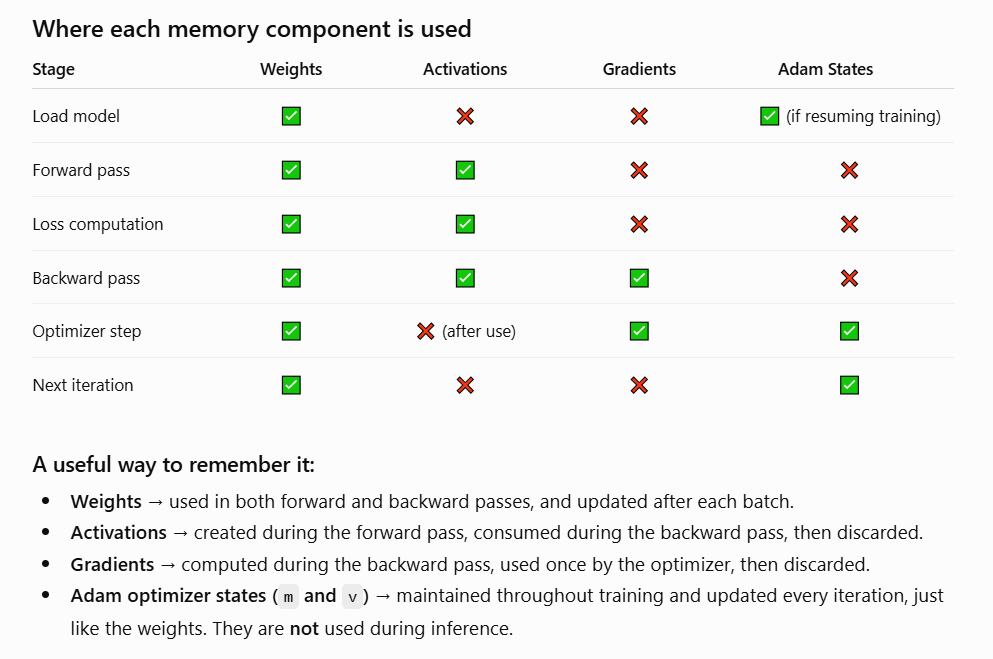

# During training a model



*   Step 1: Load Model Parameters (Weights)

Memory used:

✅ Model parameters (4 bytes/parameter)

At this point, only the weights need to be in GPU memory.


*   Step 2: Forward Pass

The input passes through the network.

Each layer computes:

Activation = f(W × Input + b)

Memory now contains:

✅ Weights

✅ Activations

These activations are stored because they are needed later for backpropagation.

*   Step 3: Compute Loss

The prediction is compared with the true label.

The loss is a single number.

No gradients yet.

Memory: Weights, Activations, Loss

*   Step 4: Backward Pass (Backpropagation)

Now we compute gradients.

The chain rule is applied from the output layer back to the input layer.

For every weight:

Gradient = ∂Loss / ∂Weight

These gradients are stored in memory.

Memory now contains:

✅ Weights
✅ Activations
✅ Gradients

*   Step 5: Optimizer Uses Its States (Adam)

Now Adam updates every weight.

Adam already stores:

m = moving average of gradients

v = moving average of squared gradients

New_Weight = Weight - learning_rate × corrected_gradient

These optimizer states persist across training iterations.

Memory contains:

Weights,
Adam state (m),
Adam state (v),
Gradients (temporarily)


*   Step 6: Update Weights

The optimizer updates the model.

Old Weight

↓

Optimizer

↓

New Weight

The weights now contain the learned information from this batch.



*   Step 7: Clear Temporary Memory

After the optimizer step:

Activations are no longer needed.
Gradients are no longer needed.

They are freed from memory (or overwritten in the next iteration).

Only these remain:

✅ Updated weights
✅ Adam optimizer states

Then the next batch starts.








Training = Weights + Activations + Gradients + Optimizer States


Inference = Weights + Activations (+ KV Cache for LLMs)

TRAINING

Weights
   │
Forward Pass
   │
Activations
   │
Loss
   │
Backward Pass
   │
Gradients
   │
Optimizer
   │
Updated Weights

INFERENCE

Weights
   │
Forward Pass
   │
Activations
   │
Prediction

Inference requires only the model weights, temporary activations, and (for Transformer-based LLMs) the KV cache. It does not require gradients or optimizer states because there is no backpropagation or weight update.

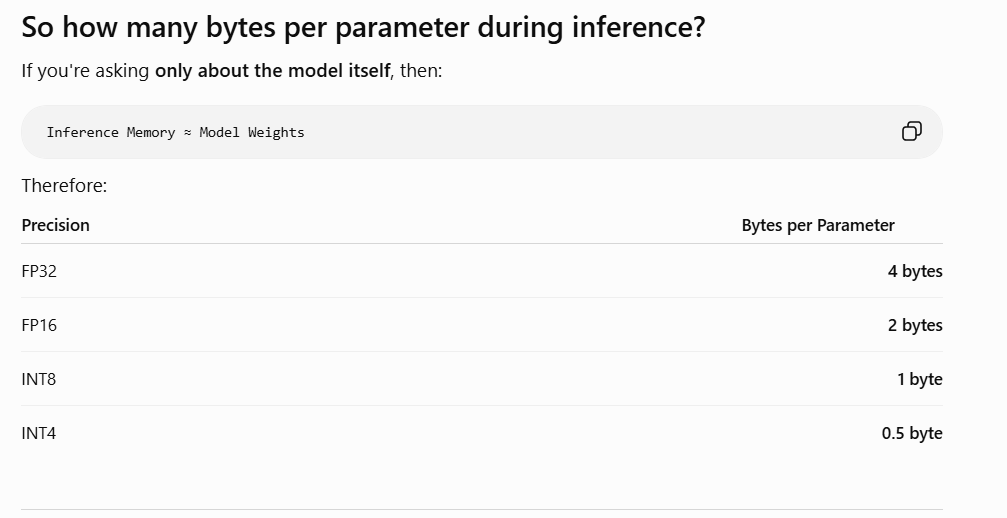

# Why are activations estimated as 8 bytes per parameter?

- The activation function itself doesn't consume 8 bytes. The memory is used to store the activations (layer outputs) generated during the forward pass. These activations must be retained until the backward pass to compute gradients. The commonly cited "8 bytes per parameter" is only a rough approximation for training memory in FP32; actual activation memory depends on the model architecture, batch size, sequence length, hidden size, and number of layers—not directly on the number of parameters.

# Activation Function:-

An activation function is a mathematical function that transforms a neuron's output before passing it to the next layer. Its primary purpose is to introduce non-linearity into the neural network.

Without activation functions, a neural network would behave like a single linear transformation regardless of how many layers it has, making it unable to learn complex patterns such as language, images, or speech.


- An activation function is a mathematical function that introduces non-linearity into a neural network, allowing it to learn complex patterns that cannot be captured by linear models alone.

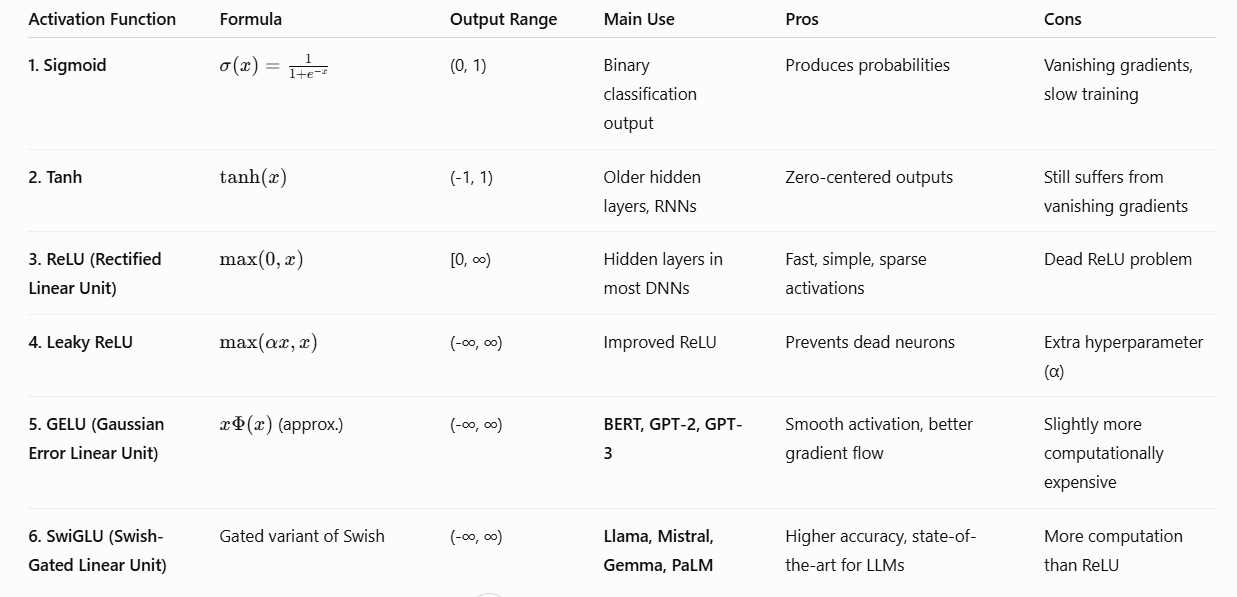

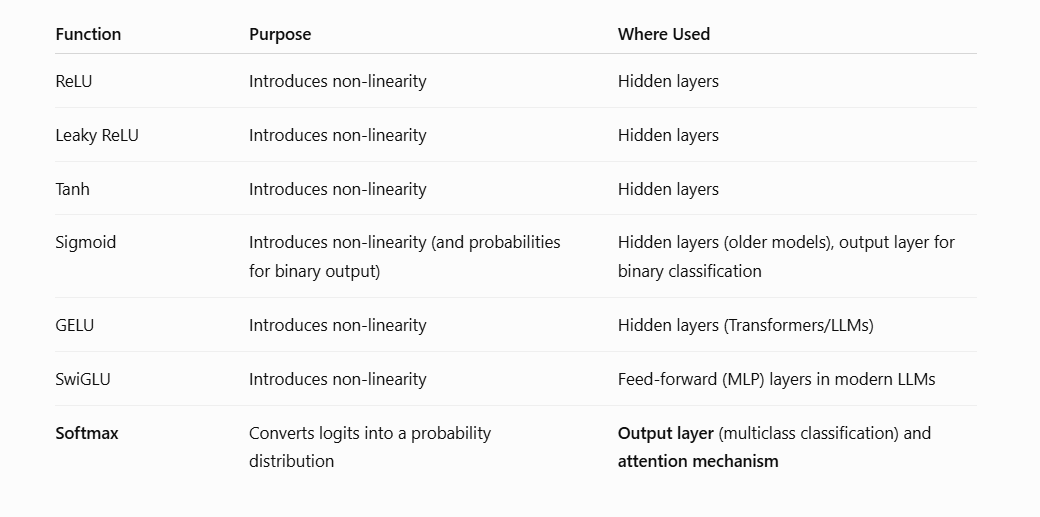

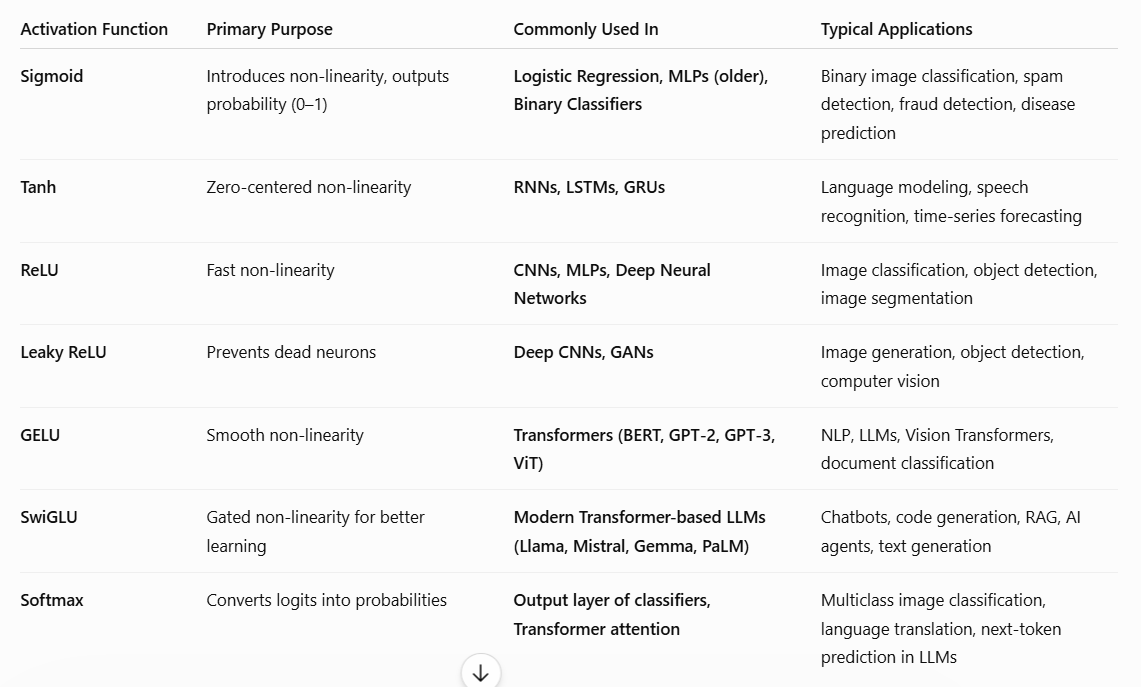

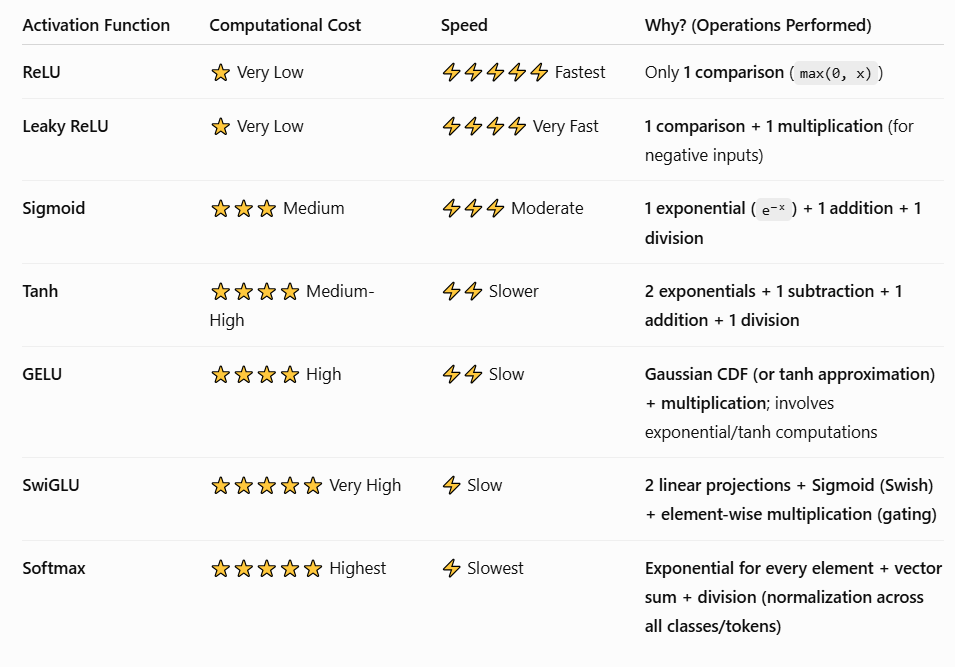

# Why exponentional computational cost greater than simple comparison cost?

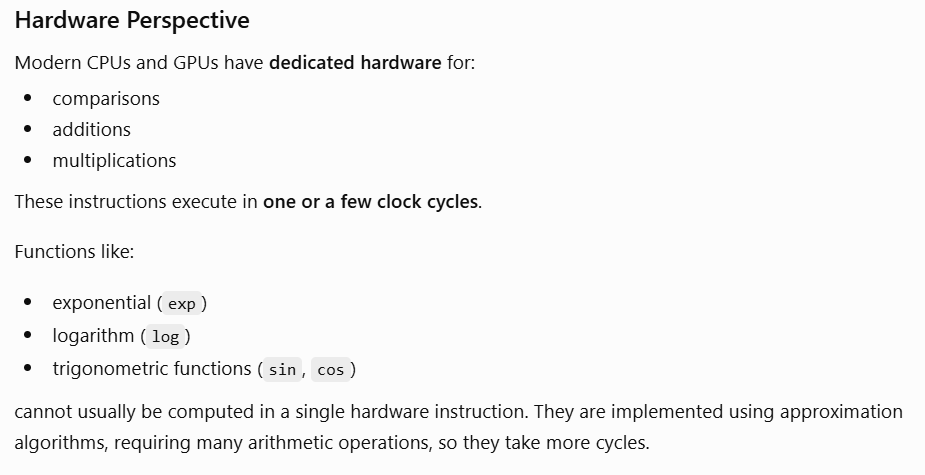

# Normalization:

Normalization is the process of making data values lie within a common range so that the model can learn faster and more efficiently.

Think of it as bringing everyone onto the same scale.


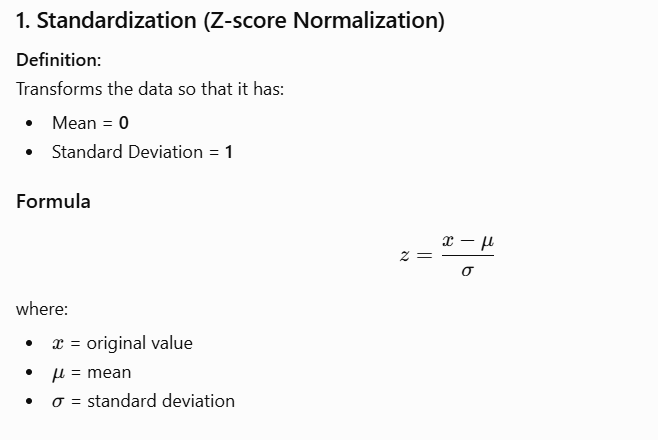

Notice:

- Mean becomes 0
- Std becomes 1
- Values are not restricted to any range


Advantages
- Handles outliers better than Min-Max scaling.
- Preserves the distribution shape.
- Preferred when data approximately follows a normal distribution.




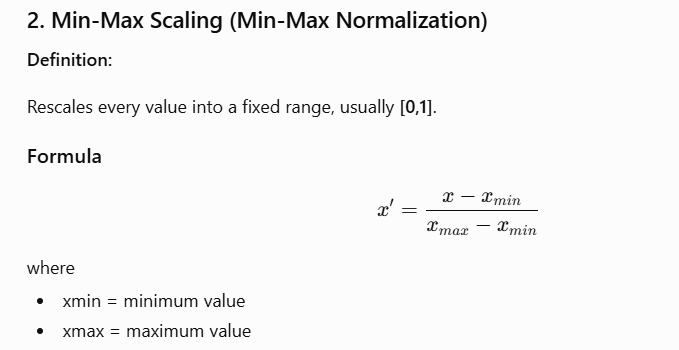


Advantages
- Easy to interpret.
- Useful when algorithms expect bounded inputs.
- Preserves relative distances between values.

Disadvantages

- Very sensitive to outliers.

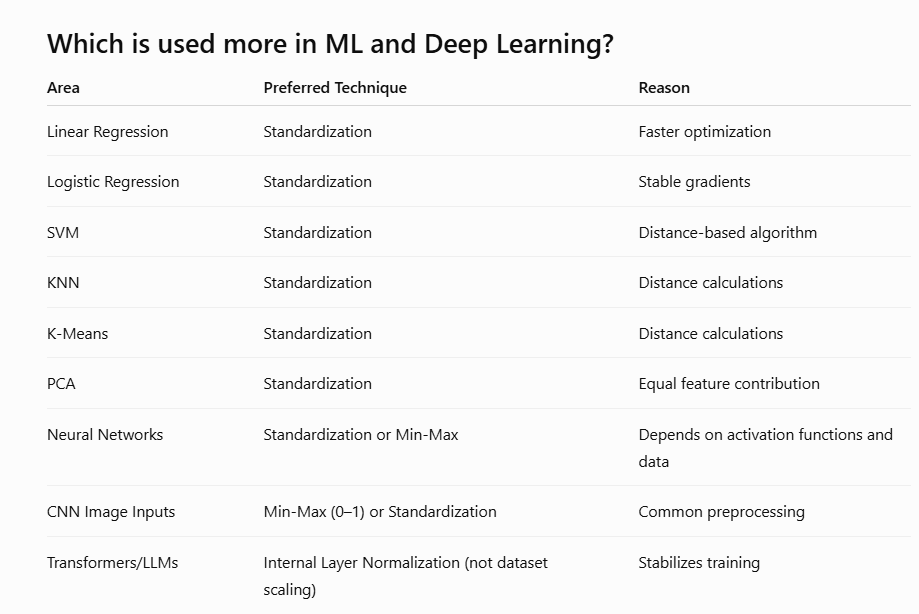

# Loss Functions:-

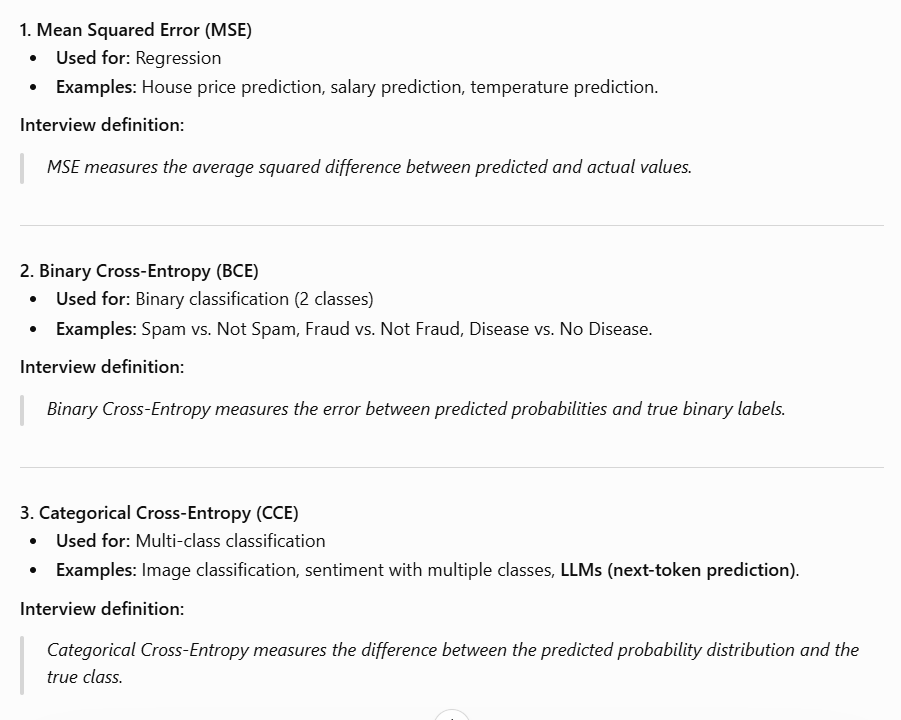

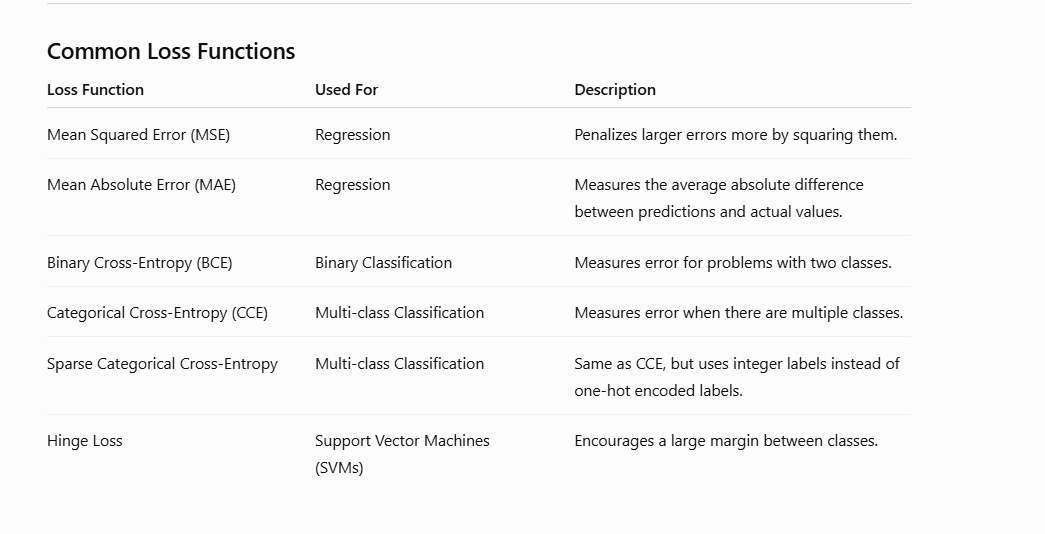

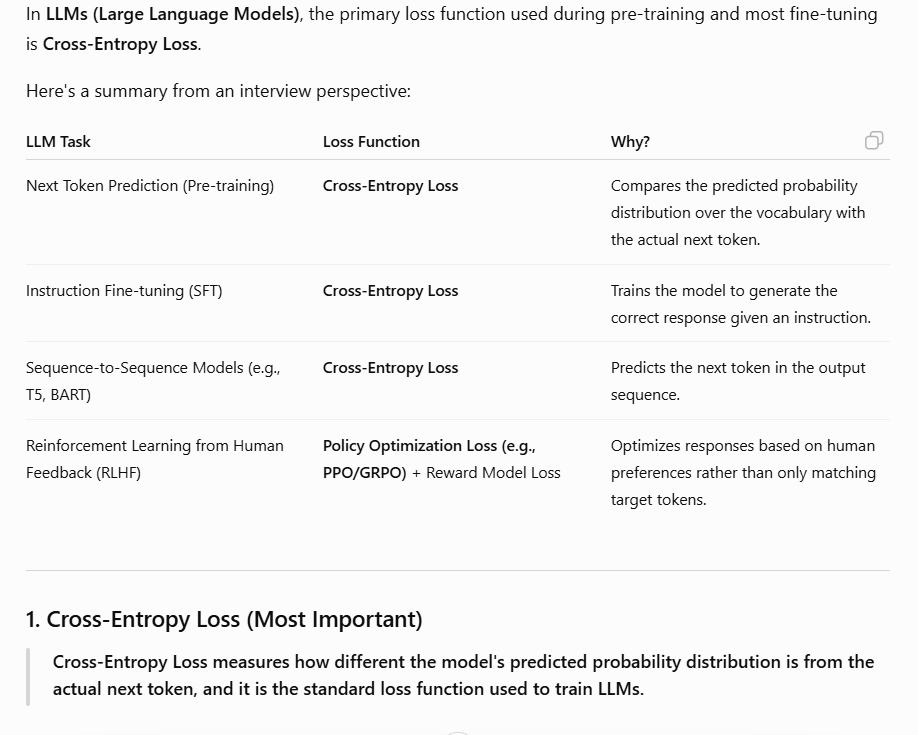

# Optimizers :-

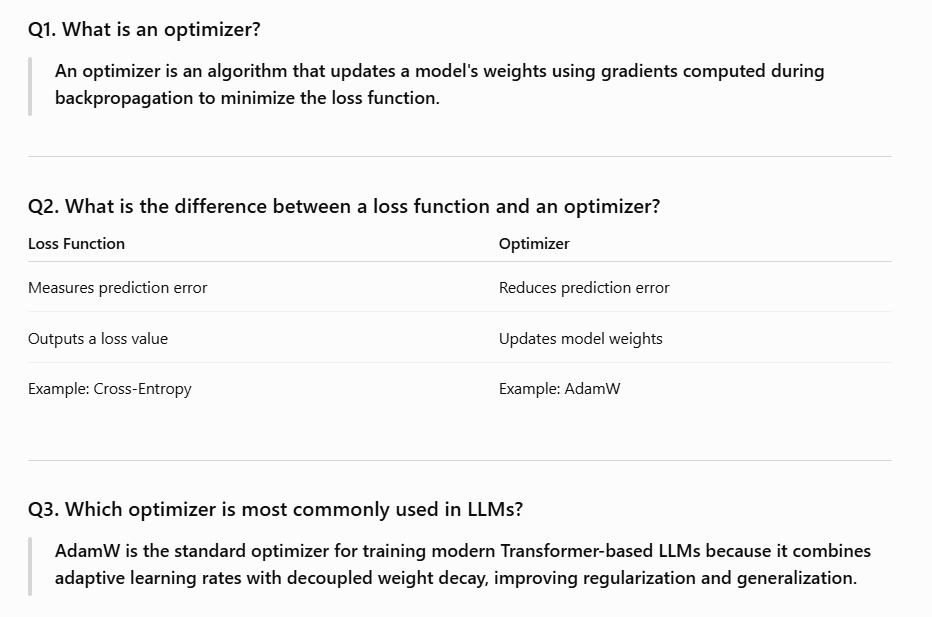

Gradient Descent is an optimization algorithm that iteratively updates the model's weights and biases in the direction that minimizes the loss function.

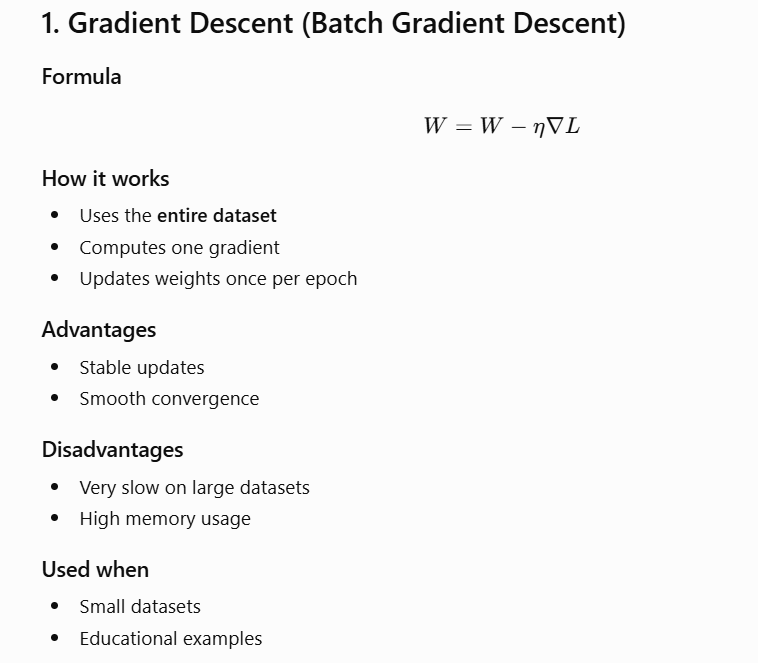

Stochastic Gradient Descent (SGD) is a variant of Gradient Descent that updates the model's parameters after processing one training example at a time, instead of the entire dataset.

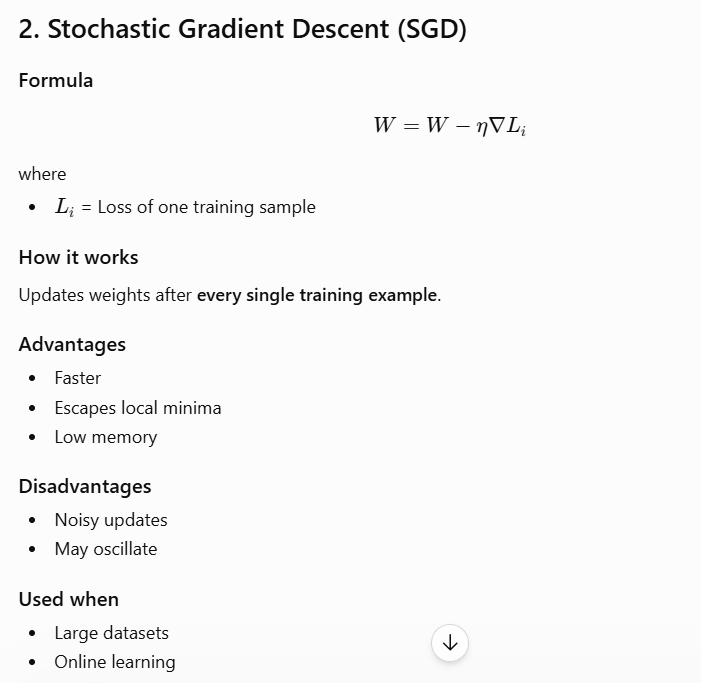

Mini-Batch Gradient Descent is an optimization algorithm that updates the model weights after computing the gradient on a small subset (mini-batch) of the training data instead of the entire dataset or a single sample. It provides a balance between training speed, memory efficiency, and stable convergence.

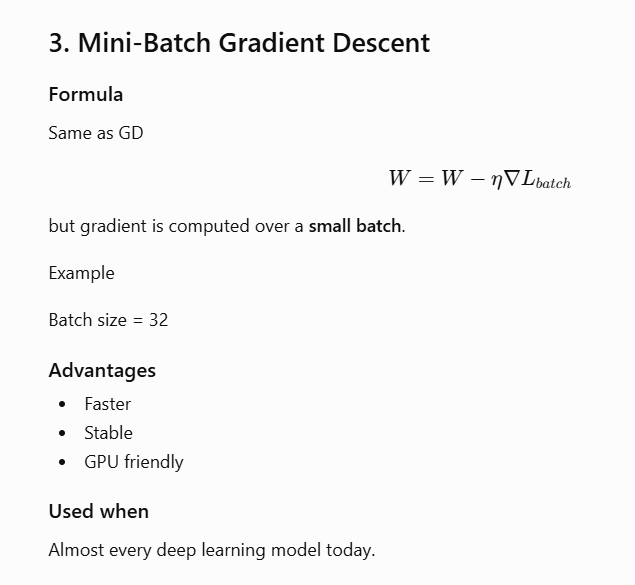

# 4) Momentum:-

Momentum is an extension of Gradient Descent that uses the current gradient along with previous updates to accelerate learning. It reduces oscillations, speeds up convergence, and helps the optimizer move more smoothly toward the minimum. It introduces a velocity term controlled by the momentum coefficient β, which is typically set to 0.9.

#Key takeaway

Momentum does not adapt the learning rate for each parameter. It only adds memory of past gradients. Adaptive optimizers such as RMSProp, Adam, and AdamW build on this idea by combining momentum with parameter-wise learning rate adaptation.


# Momentum:- Which diection should i keep moving?

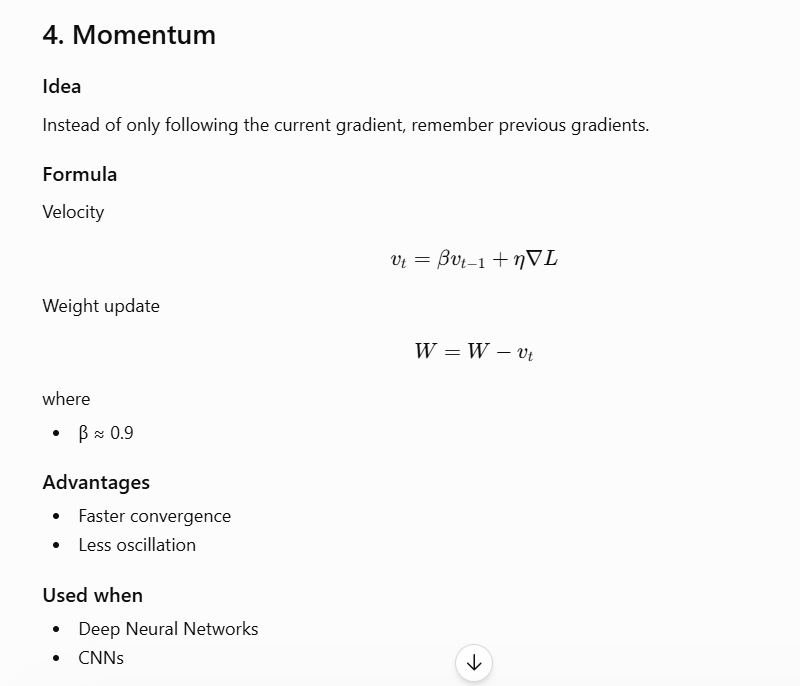

# 5) Adaptive Gradient:-
AdaGrad (Adaptive Gradient) is an optimizer that adapts the learning rate for each parameter individually by accumulating past squared gradients. Parameters that receive large or frequent updates get smaller learning rates, while rarely updated parameters get larger learning rates. It works well for sparse data but is less commonly used today because its learning rate continuously decreases, making training slow.

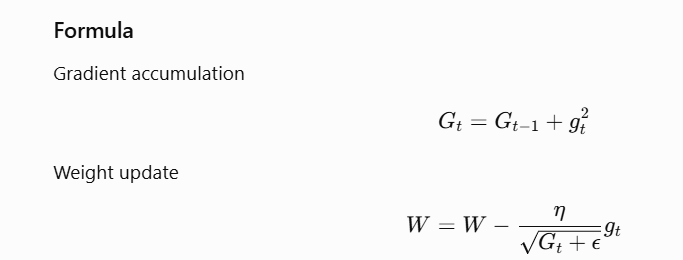

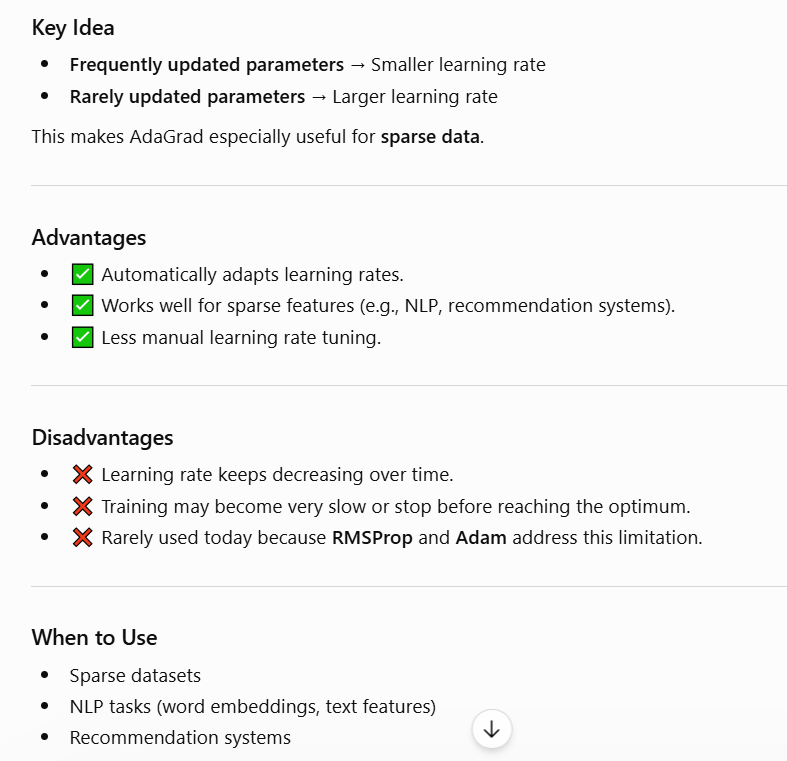

# 6) RMSProp:-

RMSProp (Root Mean Square Propagation) is an adaptive optimizer that adjusts the learning rate for each parameter using an exponentially weighted moving average of squared gradients. Unlike AdaGrad, it does not let the learning rate shrink indefinitely, resulting in faster and more stable convergence. It is commonly used for deep neural networks and RNNs.

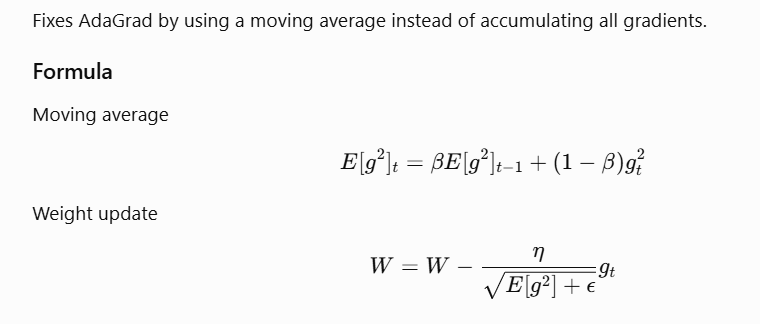

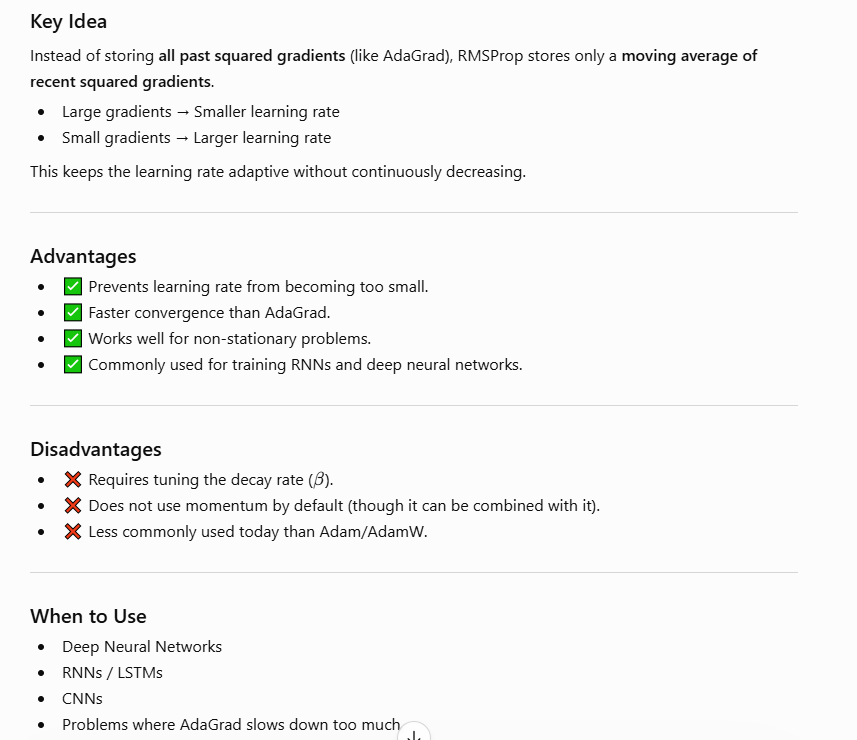

# 7) Adam:-
Adam (Adaptive Moment Estimation) is an optimizer that combines Momentum and RMSProp. It uses the moving average of gradients to accelerate convergence and the moving average of squared gradients to adapt the learning rate for each parameter. This results in fast, stable training and makes Adam one of the most widely used optimizers in deep learning.



Adam works as below:-
- Step-1: Calculate the gradient:
    - Find which direction reduces the loss.

- Step-2: Momentum:
    - Don't trust only the current gradient.
    - Also consider the previous gradients.
    - This gives a smoother, more reliable direction.

- Step-3: RMSProp:
    - Look at the recent gradient magnitudes.
    - If gradients are large(steep downhill) - take smaller steps
        - If we take the a large step on a steep slope - we might - overshoot the bottom, or end up on the other side, or keep jumping back and forth
    - If gradients are small(flat road) - take larger steps

- step-4: Update the weight:
    - Move in the momentum direction using the RMSProp-adjusted step size.

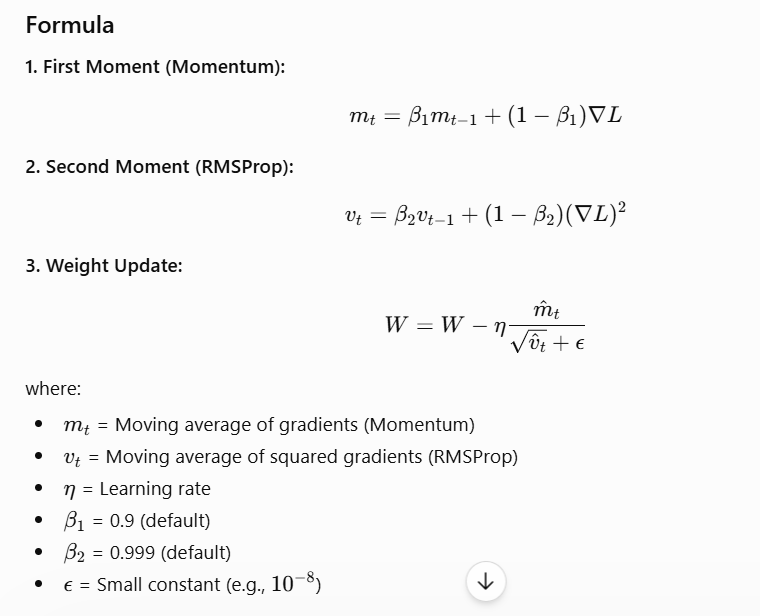

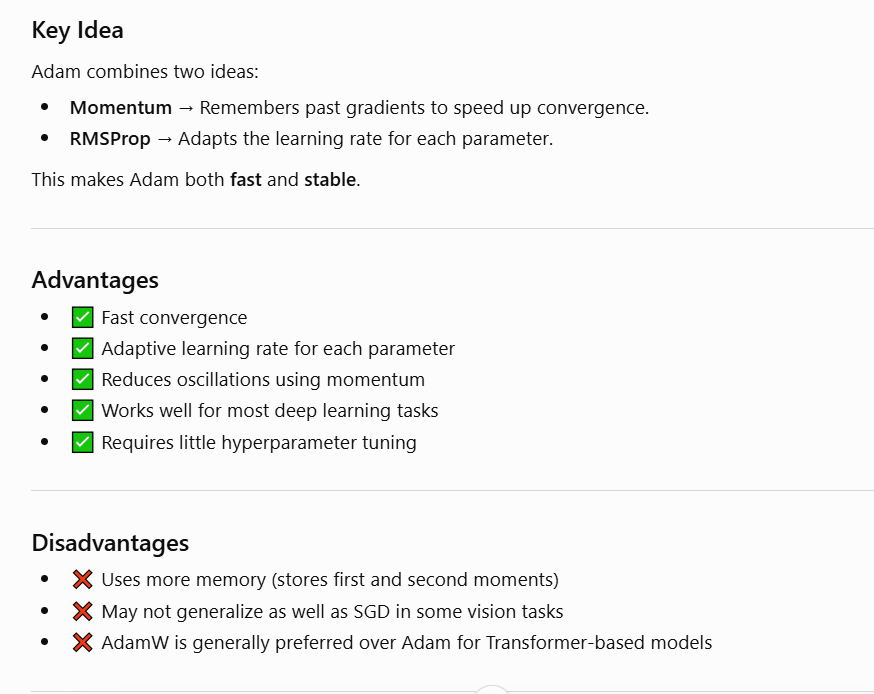

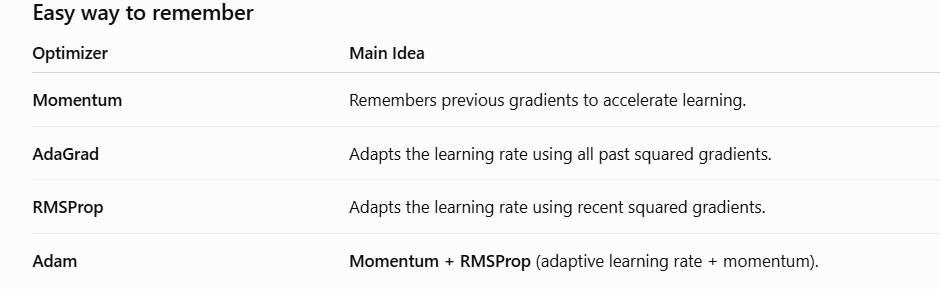

# 8) AdamW

AdamW (Adam with Decoupled Weight Decay) is an improved version of Adam that applies weight decay separately from the gradient update. This improves regularization, reduces overfitting, and leads to better generalization. It is the default optimizer for modern Transformer-based models such as BERT, GPT, LLaMA, and most LLMs.

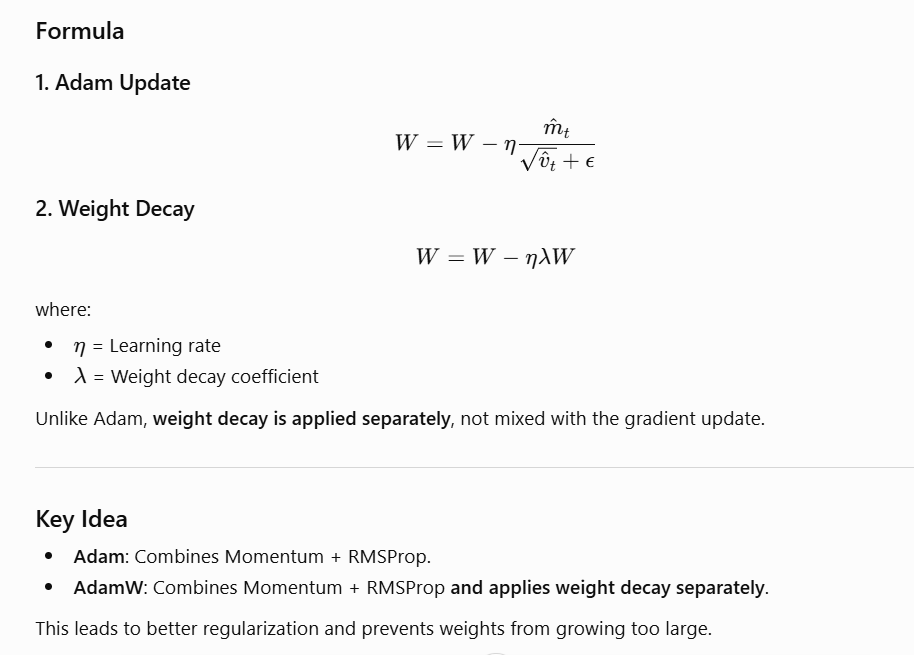

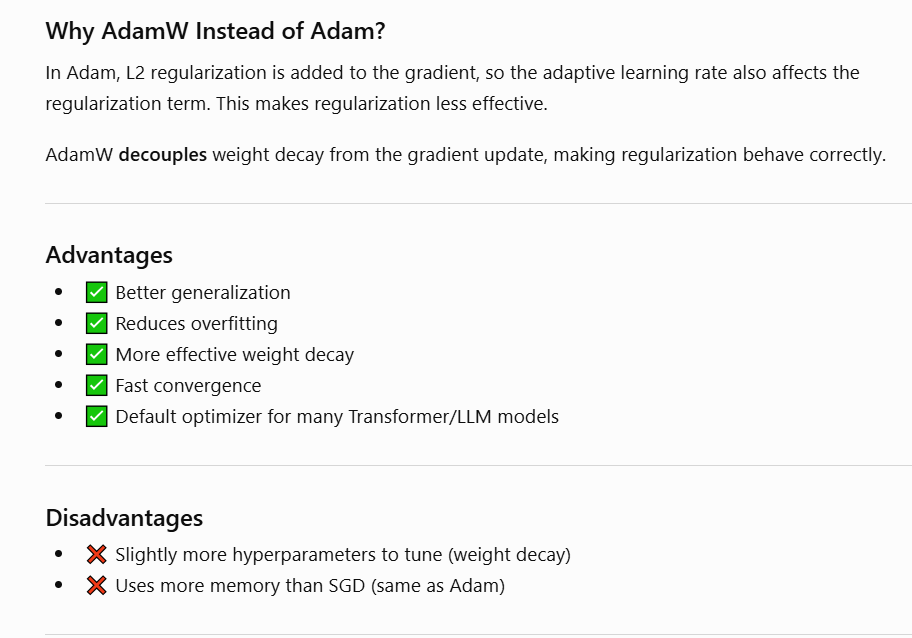

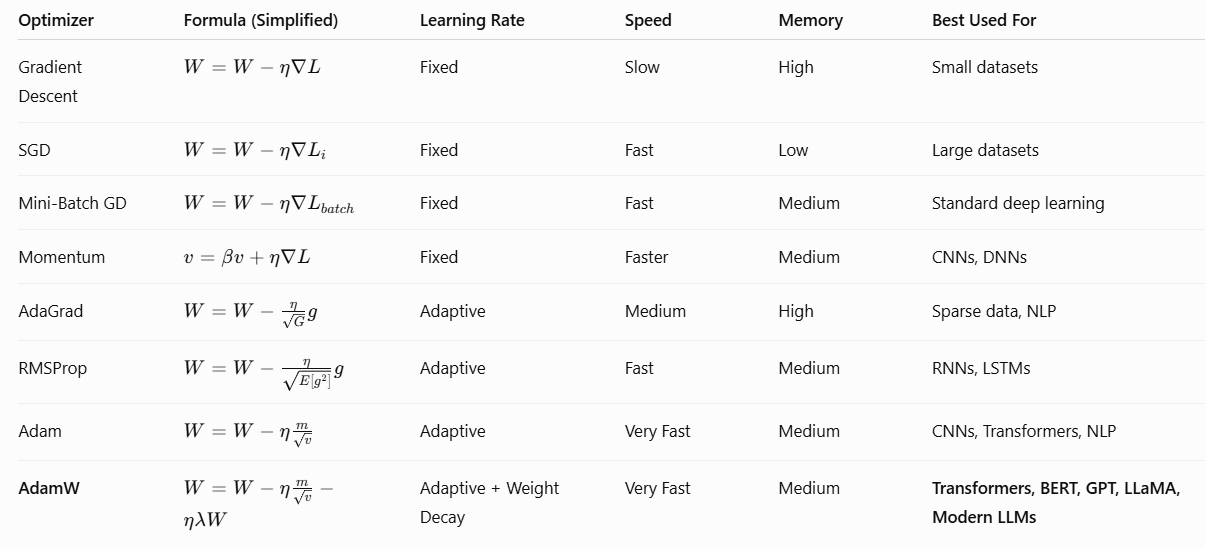

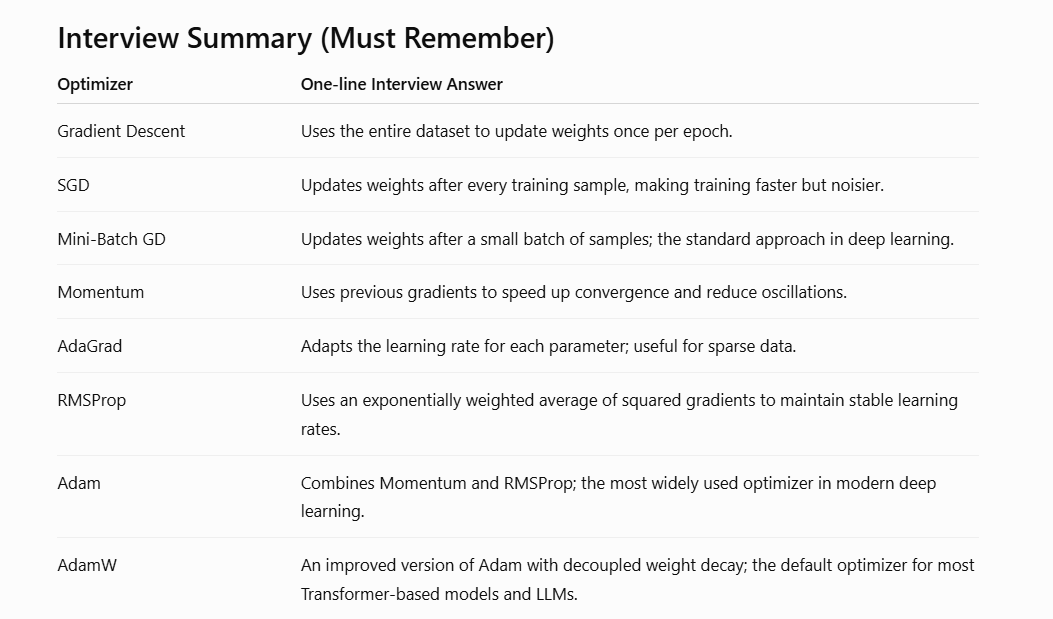

# Regularization Techniques:-

Regularization is a technique used to reduce overfitting by adding constraints or penalties to the model, so the model generalize better on unseen data.

- For Neural Networks specifically
    - To lower the weights of the network

Overfitting - Overfitting is when a model closely fits the traing data so much, that it is not able to generalize well to the real world

Overfitting occurs when a model learns the training data too well, including its noise and irrelevant patterns, resulting in high training accuracy but poor performance on unseen data.


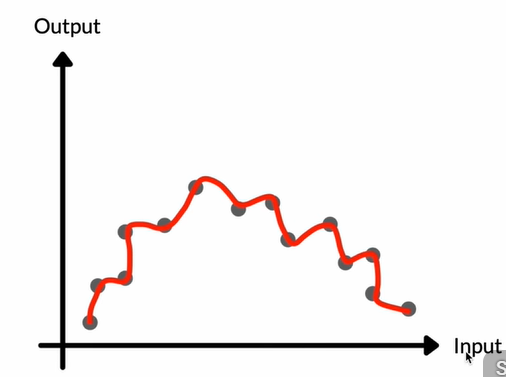

# How to understand if a model is Overfitting

we will look at as we train our model more and more if as we use more epochs. After some time validation loss will start getting higher whereas the training losses keeps getting lower and lower and we know from that point on. We started to overfit because our model learns more closely what is being represented in the training data set whereas it is not able to really understand what's going on with the validation data set or generally in the real world. It is not really able to understand the pattern and the data well anymore.

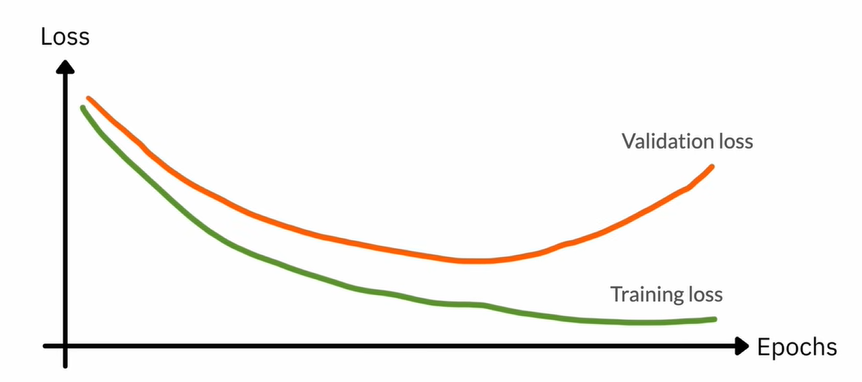

# Overfitting means high variance

Variance measures how much a model's predictions change when it is trained on different training datasets. A high-variance model is very sensitive to small changes in the training data, often leading to overfitting.

➡️ High Variance
- The model's performance changed significantly due to a small change in the training data.

➡️ Low Variance
The model behaves consistently even when the training data changes slightly.

If a small change in the training data causes a large change in the model's predictions, the model has high variance.

- A lot of flexibility (parameters) in the model causes high variance.

- Models such as Random Forests and Neural Networks tend to have high variance.

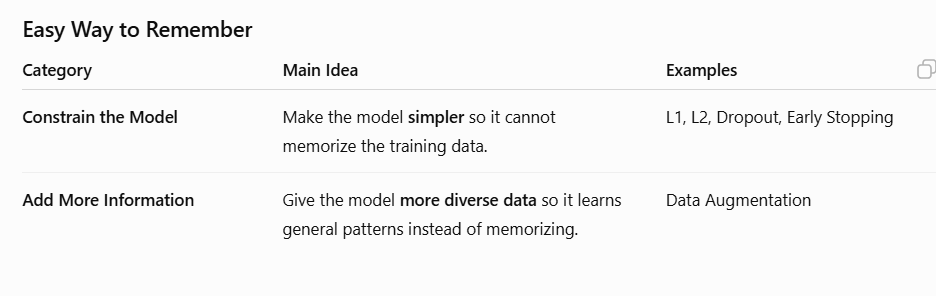

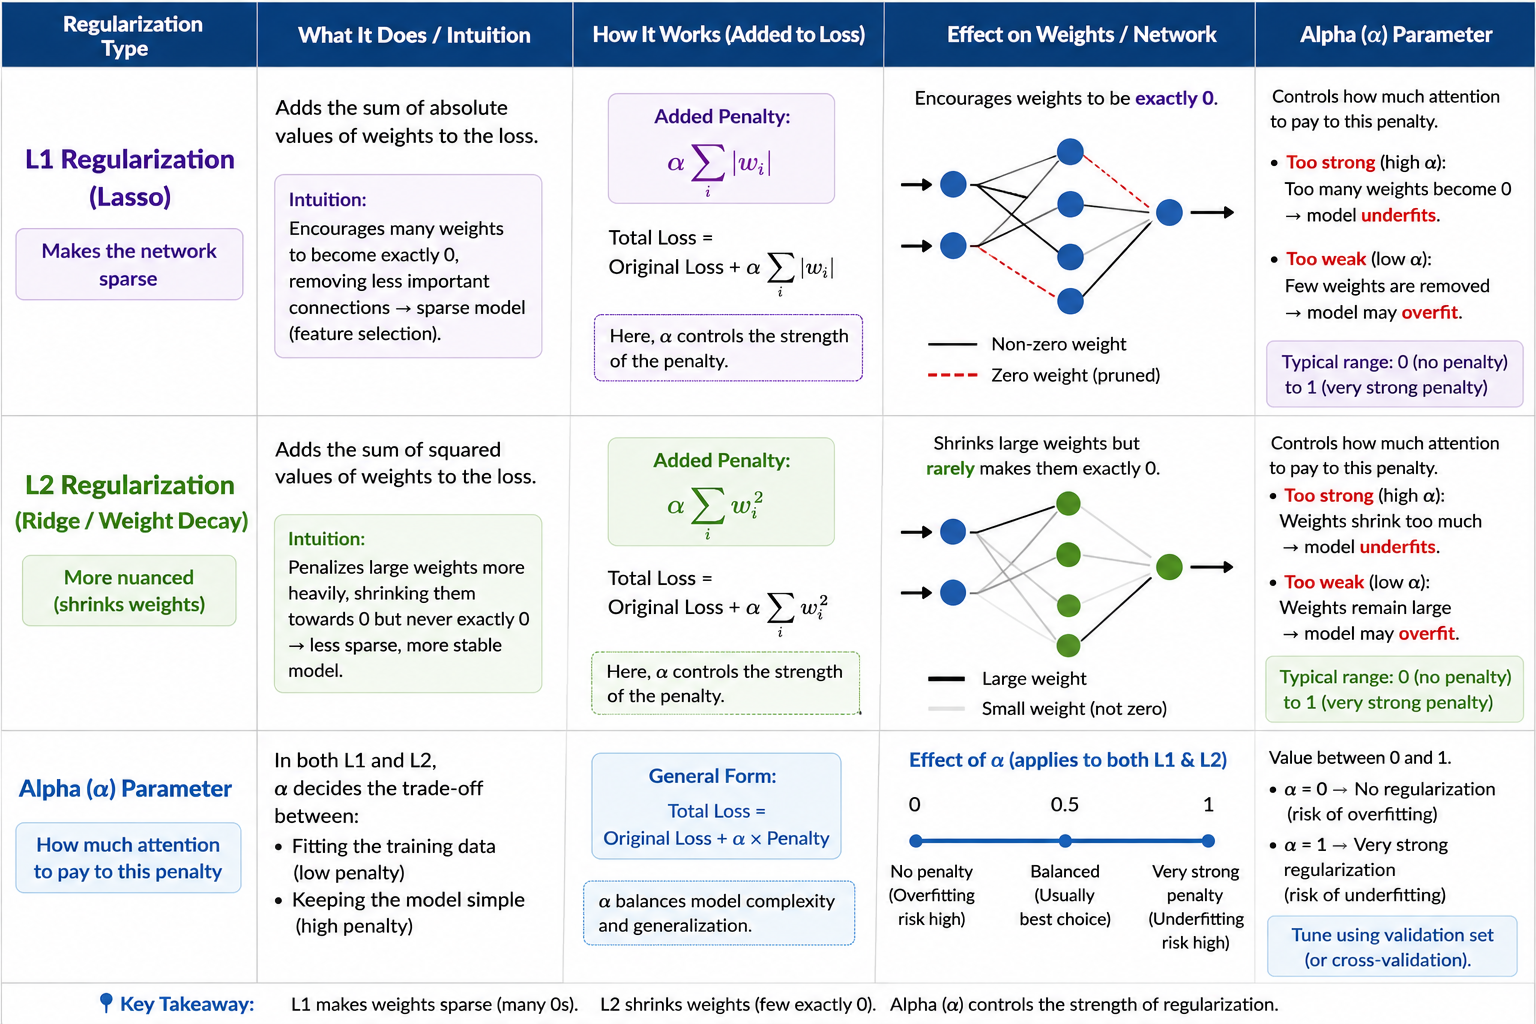

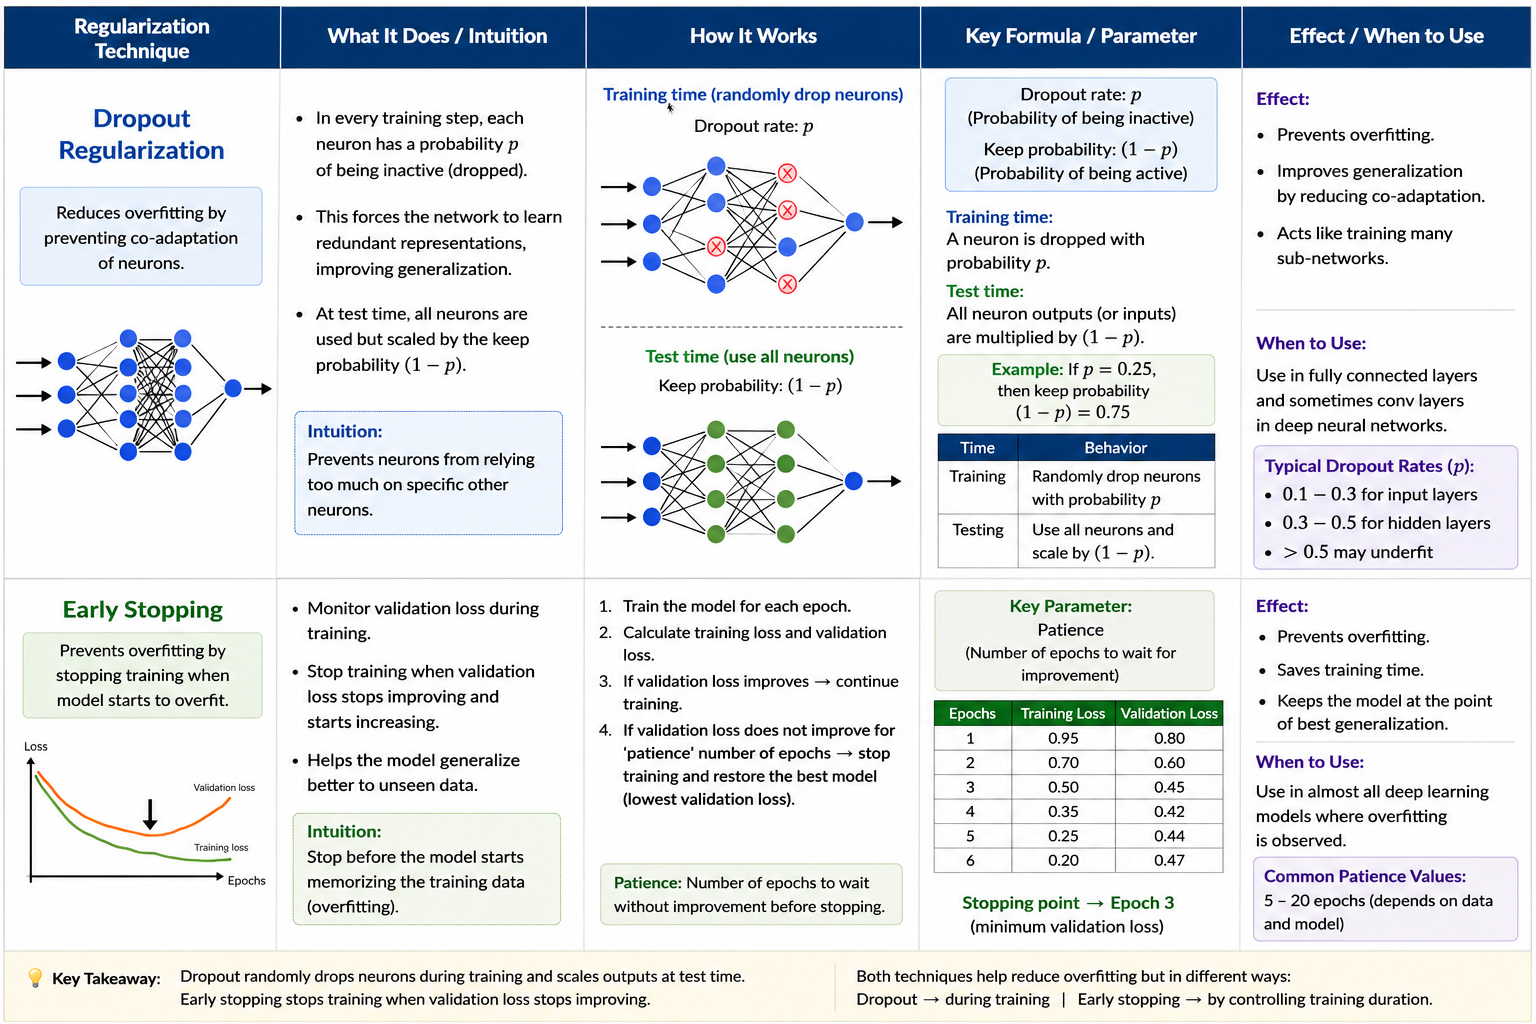

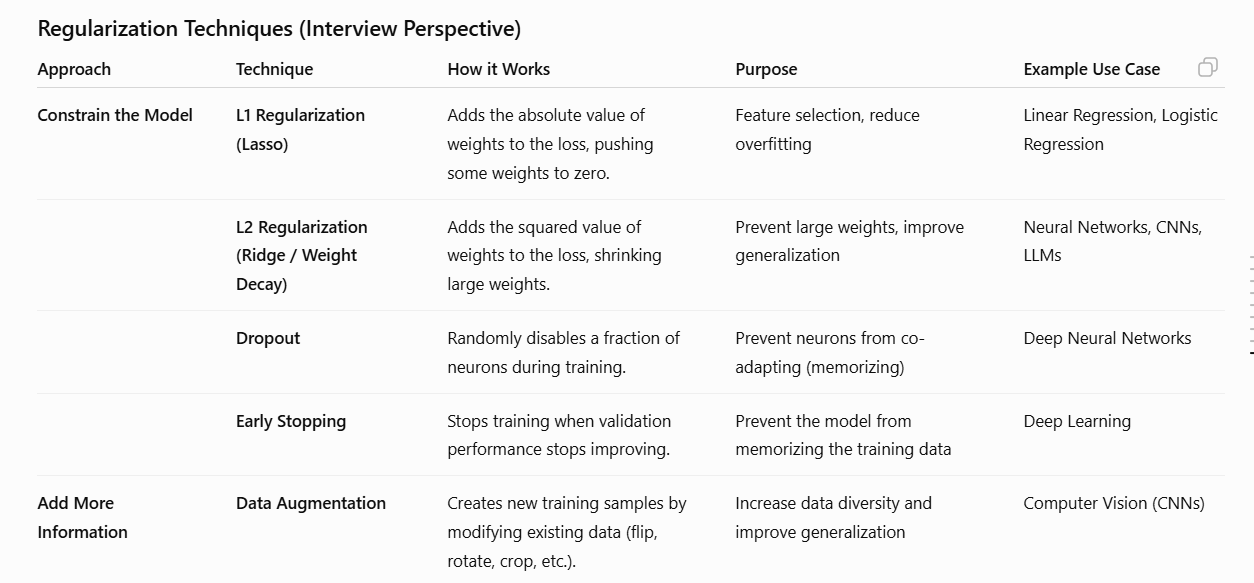